# Assignment - 16 : SVM, Trees, Ensembles, Validation & Unsupervised Learning

## Name - Suryansh Tiwari

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

from sklearn.svm import SVC

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    RandomForestClassifier
)

from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")
df.columns = df.columns.str.strip()
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [3]:
median_value = df["Total Amount"].median()
df["Revenue Category"] = np.where(
    df["Total Amount"] >= median_value,
    1,
    0
)
print(df["Revenue Category"].value_counts())

Revenue Category
1    500
0    500
Name: count, dtype: int64


In [4]:
X = df[
    [
        "Age",
        "Quantity",
        "Price per Unit"
    ]
]

y = df["Revenue Category"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

## Part-1 : Support Vector Machine

In [6]:
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train,y_train)
linear_pred = svm_linear.predict(X_test)
linear_acc = accuracy_score(y_test,linear_pred)
print("Linear Kernel Accuracy:",linear_acc)

Linear Kernel Accuracy: 1.0


In [7]:
svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X_train,y_train)
rbf_pred = svm_rbf.predict(X_test)
rbf_acc = accuracy_score(y_test,rbf_pred)
print("RBF Kernel Accuracy:",rbf_acc)

RBF Kernel Accuracy: 0.87


In [8]:
print("Linear Kernel Accuracy :",linear_acc)

print("RBF Kernel Accuracy :",rbf_acc)

Linear Kernel Accuracy : 1.0
RBF Kernel Accuracy : 0.87


## Part-1 : Decision Tree

In [9]:
tree = DecisionTreeClassifier(max_depth=3,random_state=42)
tree.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

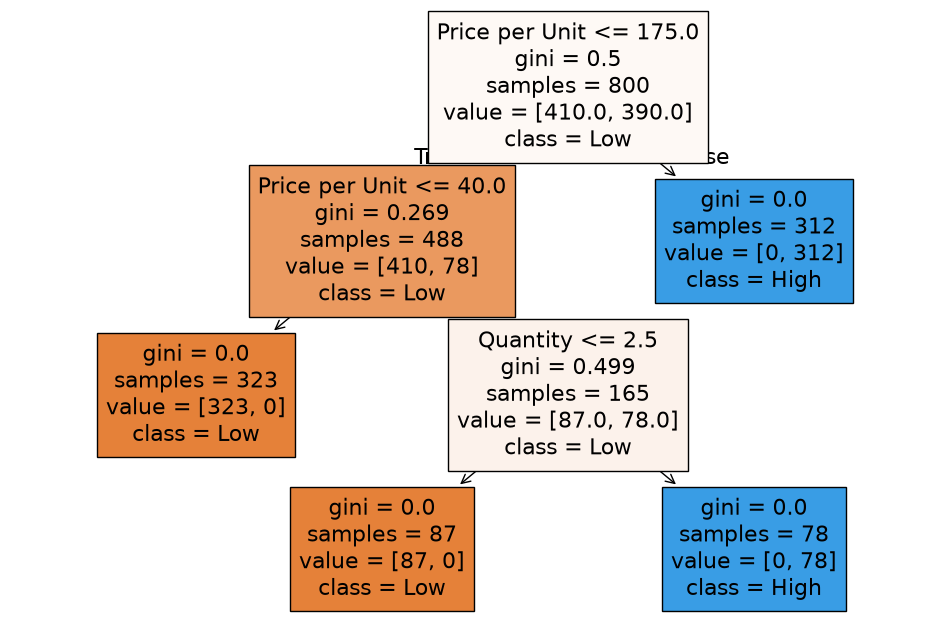

In [10]:
plt.figure(figsize=(12,8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Low","High"],
    filled=True
)
plt.show()

In [11]:
small_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)
small_tree.fit(X_train,y_train)
print("Training Accuracy:",small_tree.score(X_train,y_train))
print("Testing Accuracy:",small_tree.score(X_test,y_test))

Training Accuracy: 0.9025
Testing Accuracy: 0.87


In [12]:
large_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)
large_tree.fit(X_train,y_train)
print("Training Accuracy:",large_tree.score(X_train,y_train))
print("Testing Accuracy:",large_tree.score(X_test,y_test))

Training Accuracy: 1.0
Testing Accuracy: 1.0


## Part-2 : Validation

In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)
print("Training :",len(X_train))
print("Validation :",len(X_validation))
print("Testing :",len(X_test))

Training : 600
Validation : 200
Testing : 200


In [14]:
validation_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
validation_model.fit(
    X_train,
    y_train
)
validation_accuracy = validation_model.score(
    X_validation,
    y_validation
)
test_accuracy = validation_model.score(
    X_test,
    y_test
)
print("Validation Accuracy:",validation_accuracy)
print("Test Accuracy:",test_accuracy)

Validation Accuracy: 1.0
Test Accuracy: 1.0


In [15]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scores = cross_val_score(
    DecisionTreeClassifier(),
    X,
    y,
    cv=kfold
)
print(scores)
print("Average Accuracy:",scores.mean())

[1. 1. 1. 1. 1.]
Average Accuracy: 1.0


In [16]:
print("Single Test Accuracy :",test_accuracy)
print("Cross Validation Accuracy :",scores.mean())

Single Test Accuracy : 1.0
Cross Validation Accuracy : 1.0


## Part-3 : Ensemble Learning

## Bagging vs Boosting

**Bagging (Bootstrap Aggregating):**
- Trains multiple models independently on random subsets of the data.
- Combines their predictions (usually by voting or averaging).
- Reduces variance and helps prevent overfitting.

**Boosting:**
- Trains models sequentially.
- Each new model focuses more on the mistakes made by the previous ones.
- Reduces both bias and variance and often improves overall performance.

In [17]:
bagging = BaggingClassifier(
    random_state=42
)
bagging.fit(
    X_train,
    y_train
)
bag_pred = bagging.predict(X_test)
bag_acc = accuracy_score(
    y_test,
    bag_pred
)
print("Bagging Accuracy:",bag_acc)

Bagging Accuracy: 1.0


In [18]:
boost = AdaBoostClassifier(
    random_state=42
)
boost.fit(
    X_train,
    y_train
)
boost_pred = boost.predict(X_test)
boost_acc = accuracy_score(
    y_test,
    boost_pred
)
print("AdaBoost Accuracy:",boost_acc)

AdaBoost Accuracy: 1.0


In [19]:
print("Bagging Accuracy:",bag_acc)
print("AdaBoost Accuracy:",boost_acc)

Bagging Accuracy: 1.0
AdaBoost Accuracy: 1.0


## Part-4 : Random Forest

In [20]:
forest = RandomForestClassifier(
    random_state=42
)
forest.fit(
    X_train,
    y_train
)
forest_pred = forest.predict(X_test)
forest_acc = accuracy_score(
    y_test,
    forest_pred
)
print("Random Forest Accuracy:",forest_acc)

Random Forest Accuracy: 1.0


In [21]:
decision_tree_accuracy = tree.score(X_test,y_test)
print("Decision Tree :",decision_tree_accuracy)
print("Bagging :",bag_acc)
print("Random Forest :",forest_acc)

Decision Tree : 1.0
Bagging : 1.0
Random Forest : 1.0


In [22]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":forest.feature_importances_
})
print(importance.sort_values(
    by="Importance",
    ascending=False
))

          Feature  Importance
2  Price per Unit    0.857717
1        Quantity    0.102360
0             Age    0.039923
